In [1]:
import pandas as pd
import numpy as np

In [2]:
np.__version__

'2.3.3'

## Predicting heart disease using machine learning
This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

We're going to take the following approach:

- Problem definition
- Data
- Evaluation
- Features
- Modelling
- Experimentation
### 1. Problem Definition
In a statement,

Given clinical parameters about a patient, can we predict whether or not they have heart disease?

### 2. Data
The original data came from the Cleavland data from the UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/heart+Disease

There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset

### 3. Evaluation
If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.

### 4. Features
This is where you'll get different information about each of the features in your data. You can do this via doing your own research (such as looking at the links above) or by talking to a subject matter expert (someone who knows about the dataset).

Create data dictionary

### Data Dictionary - Heart Disease Dataset

| Variable | Description | Data Type | Values / Categories | Clinical Notes |
| :--- | :--- | :--- | :--- | :--- |
| **`age`** | Patient age in years | Numeric (Integer) | Continuous age | |
| **`sex`** | Patient gender | Categorical | `1` = Male<br>`0` = Female | |
| **`cp`** | Chest pain type | Categorical | `0`: Typical angina<br>`1`: Atypical angina<br>`2`: Non-anginal pain<br>`3`: Asymptomatic | **0:** Decreased blood supply to the heart.<br>**1:** Pain not related to the heart.<br>**2:** Typically esophageal spasms.<br>**3:** No signs of heart disease. |
| **`trestbps`** | Resting blood pressure (on hospital admission) | Numeric (mm Hg) | Blood pressure measurement | Values above **130–140 mm Hg** are typically cause for concern. |
| **`chol`** | Serum cholesterol in mg/dl | Numeric (mg/dl) | Total serum cholesterol ($\text{LDL} + \text{HDL} + 0.2 \times \text{triglycerides}$) | Values above **200 mg/dl** are cause for concern. |
| **`fbs`** | Fasting blood sugar > 120 mg/dl | Categorical (Binary) | `1` = True ($> 120\text{ mg/dl}$)<br>`0` = False ($\le 120\text{ mg/dl}$) | Values $> 126\text{ mg/dl}$ signal diabetes. |
| **`restecg`** | Resting electrocardiographic results | Categorical | `0`: Nothing to note<br>`1`: ST-T Wave abnormality<br>`2`: Left ventricular hypertrophy | **1:** Signals non-normal heartbeat (mild to severe symptoms).<br>**2:** Enlarged main pumping chamber of the heart. |
| **`thalach`** | Maximum heart rate achieved | Numeric (bpm) | Maximum heart rate | |
| **`exang`** | Exercise-induced angina | Categorical (Binary) | `1` = Yes<br>`0` = No | |
| **`oldpeak`** | ST depression induced by exercise relative to rest | Numeric (Float) | ST depression value | Evaluates heart stress during exercise; an unhealthy heart stresses more. |
| **`slope`** | Slope of the peak exercise ST segment | Categorical | `0`: Upsloping<br>`1`: Flat sloping<br>`2`: Downsloping | **0:** Better heart rate with exercise (uncommon).<br>**1:** Minimal change (typical healthy heart).<br>**2:** Signs of an unhealthy heart. |
| **`ca`** | Number of major vessels (0–3) colored by fluoroscopy | Numeric (Integer) | `0`, `1`, `2`, `3` | Colored vessel indicates visible blood movement; more movement means fewer clots. |
| **`thal`** | Thallium stress test result | Categorical | `1`, `3`: Normal<br>`6`: Fixed defect<br>`7`: Reversible defect | **6:** Past defect, currently stable.<br>**7:** Improper blood movement during exercise. |
| **`target`** | Presence of heart disease | Categorical (Binary) | `1` = Disease present<br>`0` = No disease | **Predicted target attribute.** |

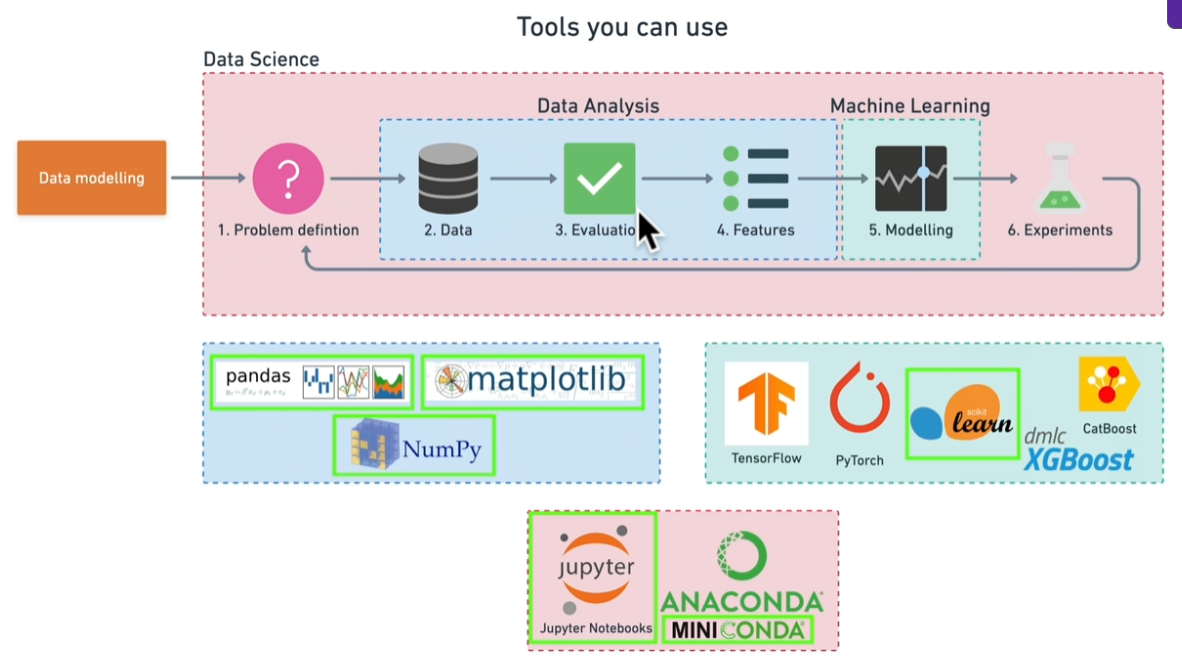

In [3]:
import sklearn
sklearn.__version__

'1.7.2'

## Preparing tools

In [4]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline 

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import RocCurveDisplay

## Load data

In [5]:
df = pd.read_csv("heart-disease.csv")
df.shape

(303, 14)

## Data Exploration (exploratory data analysis or EDA)
The goal here is to find out more about the data and become a subject matter export on the dataset you're working with.

- What question(s) are you trying to solve?
- What kind of data do we have and how do we treat different types?
- What's missing from the data and how do you deal with it?
- Where are the outliers and why should you care about them?
- How can you add, change or remove features to get more out of your data?

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

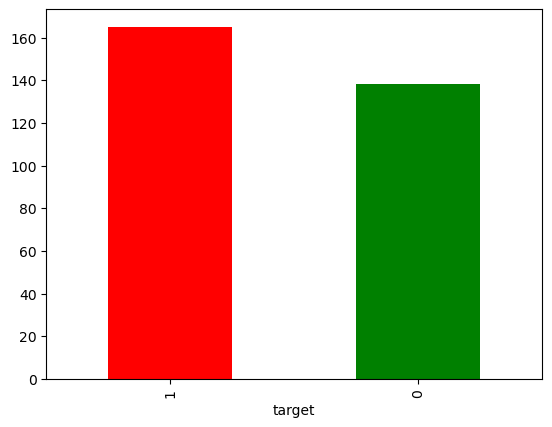

In [8]:
df['target'].value_counts().plot(kind="bar", color=["red", "green"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to Sex

In [12]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [13]:
# Compare target column with sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


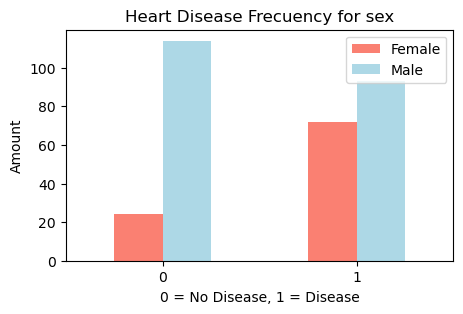

In [14]:
# Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(
    kind='bar',
    figsize=(5, 3),
    color=["salmon", "lightblue"]
)
plt.title("Heart Disease Frecuency for sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0);

### Age vs Max Heart Rate for Heart Disease

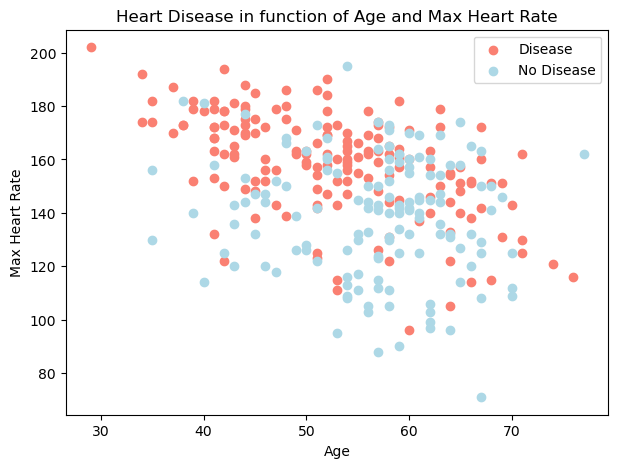

In [15]:
# Create another figure
plt.figure(figsize=(7, 5))

# Scatter with positive examples
plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c='salmon')


# Scatter with negative examples
plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c='lightblue')

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

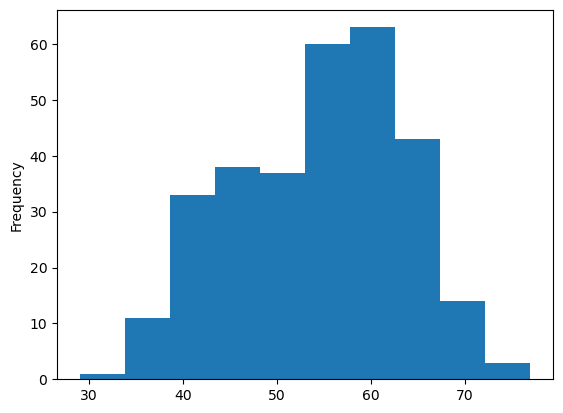

In [16]:
# Check the distribution of the age column with a histogram
df.age.plot.hist();

### Heart Disease Frequency per Chest Pain Type

**`cp`** Chest pain type 

`0`: Typical angina<br>`1`: Atypical angina<br>`2`: Non-anginal pain<br>`3`: Asymptomatic


In [17]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


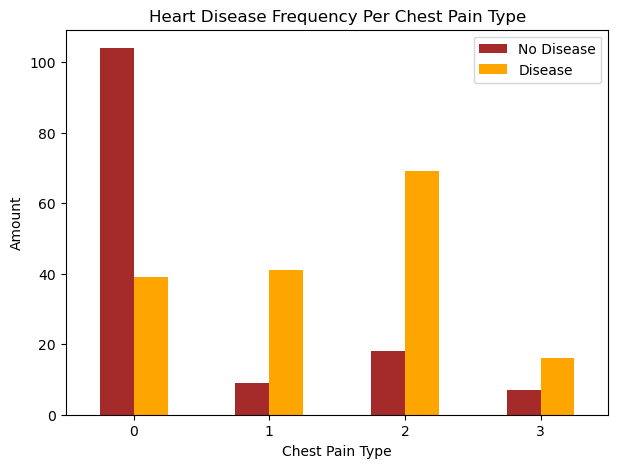

In [18]:
# Make the crosstab more visual
pd.crosstab(df.cp, df.target).plot(kind='bar',
                                   figsize=(7, 5),
                                   color=["brown", 'orange'])
# Add some communication
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

In [19]:
# Make a correlation
# method calculates the relationship strengths between all numeric columns 
df.corr() # Compute pairwise correlation of columns, excluding NA/null values.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


(14.5, -0.5)

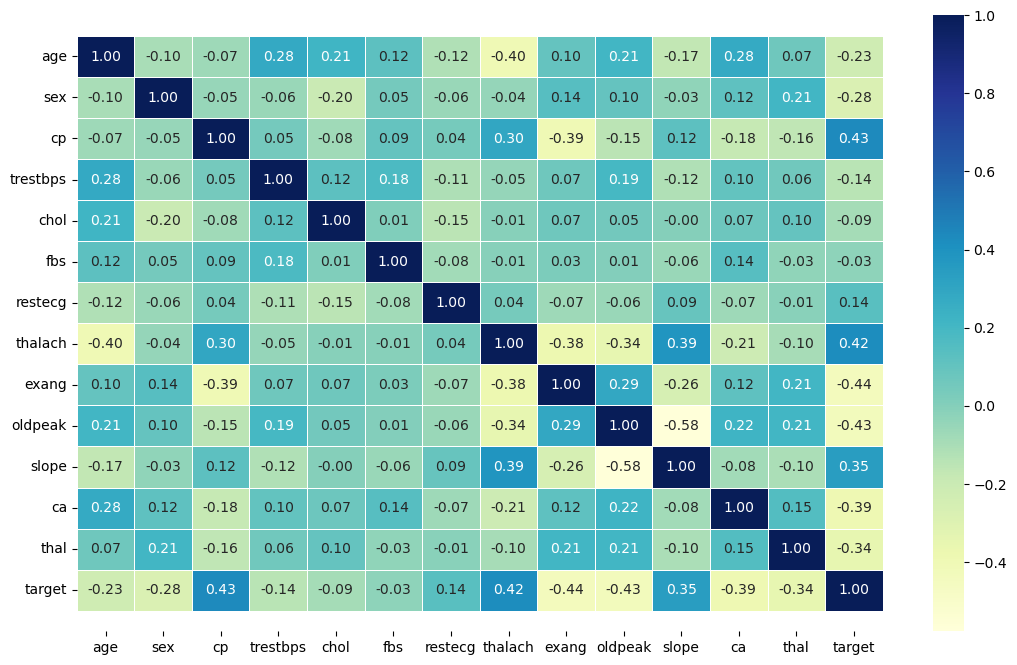

In [20]:
# Let's make our correlation matrix a little prettier
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(13, 8))
ax = sns.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt=".2f", cmap="YlGnBu")
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

## 5. Modelling

In [21]:
# Split data into X and y
X = df.drop("target", axis=1)
y = df["target"]

np.random.seed(42)

# Split into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Find the patterns on training set and test it on the test set

We're going to try 3 differente machine learning models:
1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier

In [22]:
# Put models in a dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest Classifier": RandomForestClassifier()
}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models: a dict of different scikit-learn ml models
    X_train: training data (no labels),
    X_test: testing data (no labels),
    y_train: training labels,
    y_test: test labels
    """
    # Set random seed
    np.random.seed(42)

    # Make a dictionary to keep models scores
    model_scores = {}

    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores 
        score = model.score(X_test, y_test)
        model_scores[name] = round(score, 4)
    return model_scores

In [23]:
model_scores = fit_and_score(models=models, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

model_scores

c:\Users\andre\Documents\udemy_vscode\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852,
 'KNN': 0.6885,
 'Random Forest Classifier': 0.8361}

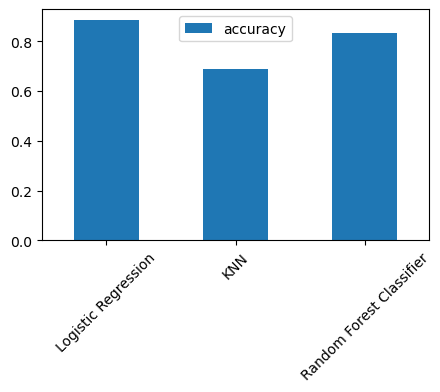

In [ ]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot(kind='bar', figsize=(5,3), rot=45);

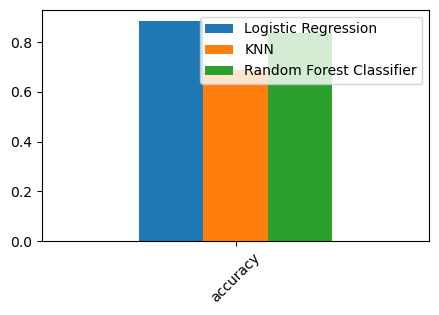

In [25]:
model_compare.plot( kind='bar', figsize=(5,3), rot=45);

Now we've got a baseline model. Let's look at the following:
- Hyperparameter tuning
- Feature importance
- Confusion matrix
- Cross-validation
- Precision
- Recall
- F1 score
- Classification report
- ROC curve
- Area under the curve (AUC)

### Hyperparameter tuning (by hand)

In [26]:
# Let's tune K-Nearest Neighbours (KNN)
train_scores = []
test_scores = []

# Create a list of different values for n_neighbors
neighbors = range(1, 21)

# Setup KNN instance
knn = KNeighborsClassifier()

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors = i)

    # Fit the algorithm
    knn.fit(X_train, y_train)

    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))

    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))


In [27]:
# Paréntesis
# np.arange and np.linspace is whether you want to define the step size or the total number of elements

# Give me numbers from 0 up to (but not including) 10, skipping by 3
arr = np.arange(0, 10, 3)
print(arr)  
# Output: [0, 3, 6, 9]

# Give me exactly 5 numbers evenly spaced between 0 and 10 (inclusive)
arr = np.linspace(0, 10, 5)
print(arr)  
# Output: [ 0.   2.5  5.   7.5 10. ]

# 10^0 to 10^3
arr = np.logspace(0, 3, num=4)
print(arr)
# Output: [   1.   10.  100. 1000.]

# 2^0 to 2^4
arr_base2 = np.logspace(0, 4, num=5, base=2)
print(arr_base2)
# Output: [ 1.  2.  4.  8. 16.]

[0 3 6 9]
[ 0.   2.5  5.   7.5 10. ]
[   1.   10.  100. 1000.]
[ 1.  2.  4.  8. 16.]


Maximun KNN score on the test data: 75.41 %


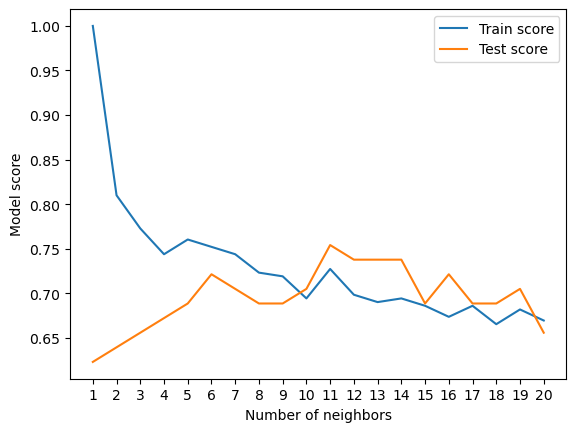

In [28]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximun KNN score on the test data: {max(test_scores)*100:.2f} %")

In [29]:
train_scores[:5], test_scores[:5]

([1.0,
  0.8099173553719008,
  0.7727272727272727,
  0.743801652892562,
  0.7603305785123967],
 [0.6229508196721312,
  0.639344262295082,
  0.6557377049180327,
  0.6721311475409836,
  0.6885245901639344])

### Hyperparameter tuning with RandomizedSearchCV
We're going to tune: 
- Logistic Regression
- Random Forest Classifier

In [30]:
# Create a hyperparameter grid for LogisticRegression

# Hyperparameter grid for Logistic Regression
log_reg_grid = {
    # C: Inverse of regularization strength (Main param: smaller values = stronger regularization)
    "C": np.logspace(-4, 4, 20),
    # solver: Algorithm to use for optimization (e.g., 'liblinear', 'lbfgs')
    "solver": ["liblinear"]
}

# Create a hyperparameter grid for RandomForestClassifier

# Hyperparameter grid for Random Forest Classifier
rf_grid = {
    # n_estimators: Number of trees in the forest (Main param: more trees usually improve performance, but slow down training)
    "n_estimators": np.arange(10, 1000, 50),
    # max_depth: Maximum depth of each tree (Main param: helps control overfitting)
    "max_depth": [None, 3, 5, 10],
    # min_samples_split: Minimum samples required to split an internal node
    "min_samples_split": np.arange(2, 20, 2),
    # min_samples_leaf: Minimum samples required to be at a leaf node (Fixed typo from 'min_samples_lead')
    "min_samples_leaf": np.arange(1, 20, 2),
}

Now we've got hyperparameter grids setup for each of our models, let's tune them using RandomizedSearchCV

#### Tune Logistic Regression 


In [ ]:
np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(
    LogisticRegression(), # Model to tune
    param_distributions=log_reg_grid, # Hyperparameter grid to search
    cv=5, # Number of cross-validation folds
    n_iter=20, # Number of parameter settings sampled
    verbose=True # Print progress logs during training
)

rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [33]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [34]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

#### Tune RandomForestClassifier 

In [ ]:
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(), # Model to tune
    param_distributions=rf_grid, # Hyperparameter grid to search
    cv=5, # Number of cross-validation folds
    n_iter=20, # Number of parameter settings sampled
    verbose=True # Print progress logs during training
)

rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [36]:
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [37]:
rs_rf.score(X_test, y_test)

0.8688524590163934

In [38]:
model_scores

{'Logistic Regression': 0.8852,
 'KNN': 0.6885,
 'Random Forest Classifier': 0.8361}

### Hyperparameter tuning with GridSearchCV
Since our LogisticRegression model provides the best scores so far, we'll try and improve them again using GridSearchCV

In [40]:
# Different hyperparameters for our LogisticRegression model
log_reg_grid = {
    # C: Inverse of regularization strength (Main param: smaller values = stronger regularization)
    "C": np.logspace(-4, 4, 30),
    # solver: Algorithm to use for optimization (e.g., 'liblinear', 'lbfgs')
    "solver": ["liblinear"]
}

# Setup random hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(
    LogisticRegression(), # Model to tune
    param_grid=log_reg_grid, # Hyperparameter grid to search
    cv=5, # Number of cross-validation folds
    verbose=True # Print progress logs during training
)

gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [41]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [42]:
gs_log_reg.score(X_test, y_test)

0.8852459016393442

## Evaluation our tuned machine learning classifier, beyond accuracy
- ROC curve and AUC score
- Confusion matrix
- Classification report
- Precision
- Recall
- F1-score

To make comparisons and evaluate our trained model, **first we need to make PREDICTIONS**

In [43]:
gs_log_reg.predict(X_test) # out model use training data to learn so it's perfect

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [44]:
# Compare predictions to truth labels to evaluate the model
y_preds = gs_log_reg.predict(X_test) # save in a variable
np.mean(y_preds == y_test) # calculate the accurracy

np.float64(0.8852459016393442)

### Confusion matrix

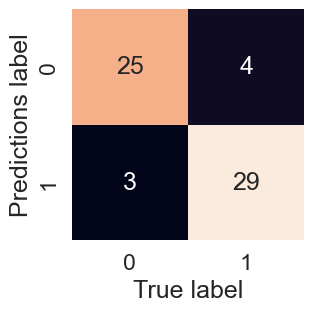

In [ ]:
import seaborn as sns
sns.set(font_scale=1.5) # Increase font size
 
def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("True label") # true labels go on the x-axis
    plt.ylabel("Predictions label") # predictions go on the y-axis

    # bottom, top = ax.get_ylim()
    # ax.set_ylim(bottom + 0.5, top - 0.5)
    
plot_conf_mat(y_test, y_preds)

### ROC Curve
ROC curve are a comparison of a model's true positive rate (tpr) versus a models false positive rate (fpr)

* True positive = model predicts 1 when truth is 1
* False positive = model predicts 1 when truth is 0
* True negative = model predicts 0 when truth is 0
* False negative = model predicts 0 when truth is 1

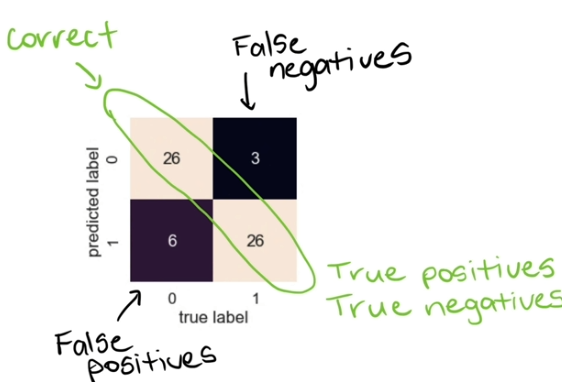

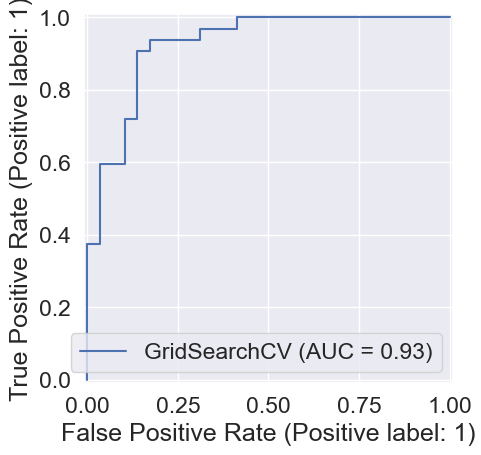

In [50]:
# Plot ROC curve and calculate AUC metric
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test);

### Classification report 
as well as cross-validated precision, recall and f1-score

In [54]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



-  **PRECISION** : Indicates the proportion of positive identifications (model predict class 1) which were actually correct. A model which produces no false positives has precision of 1.0

- **RECAL** : Indicates the proportion of actual positives which were correctly classified. A model which produces no false negatives has a recall of 1.0.

- **F1 SCORE** : A combination of precision and recall. A perfect model archieves an F1 score of 1.0

- **SUPPORT** : The number of samples each metric was calculated on.

- **ACCURACY** : The accuracy of the model in decimal form. Perfect accuracy is equal to 1.0

- **MACRO AVG**:  The avg precision, recall and F1 score between classes. Macro avg does not class imbalance into effort, so if you do have class imbalances, pay attention to this metric

- **WEIGHTED AVG**: The weighted avg precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to many samples there are in each class. This metric will favour the majority class (e.g. will give a high value when one class out performs another due to having more samples)

In [55]:
#### When precision and recall become valuable
# TPR = TP / (TP + FN) # RECALL / SENSIBILIDAD
# FPR = FP / (FP + TN) # 1-ESPECIFICIDAD

# PRECISION = TP / (TP + FP)